In [132]:
## Load all modules 

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [4]:
ds = xr.open_dataset('GLORYS12v1_Climatology.nc').squeeze()

## Temperature

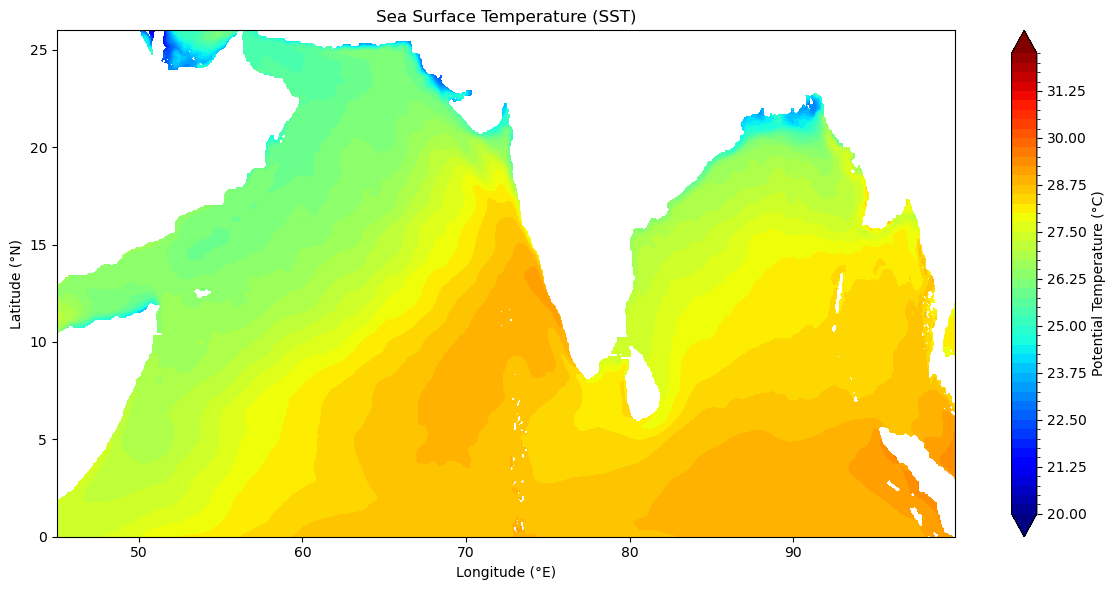

In [34]:
# Select Variable and Month
sst = ds['thetao'].sel(time='2004-12').squeeze()

# Spatial contourf plot
plt.figure(figsize=(12, 6))

sst.plot.contourf(
    x='longitude',
    y='latitude',
    cmap='jet',
    levels=np.arange(20, 32.5, 0.25),
    extend='both',
    cbar_kwargs={
        'label': 'Potential Temperature (°C)'
    }
)

plt.xlabel('Longitude (°E)')
plt.ylabel('Latitude (°N)')
plt.title('Sea Surface Temperature (SST)')

plt.tight_layout()
plt.show()

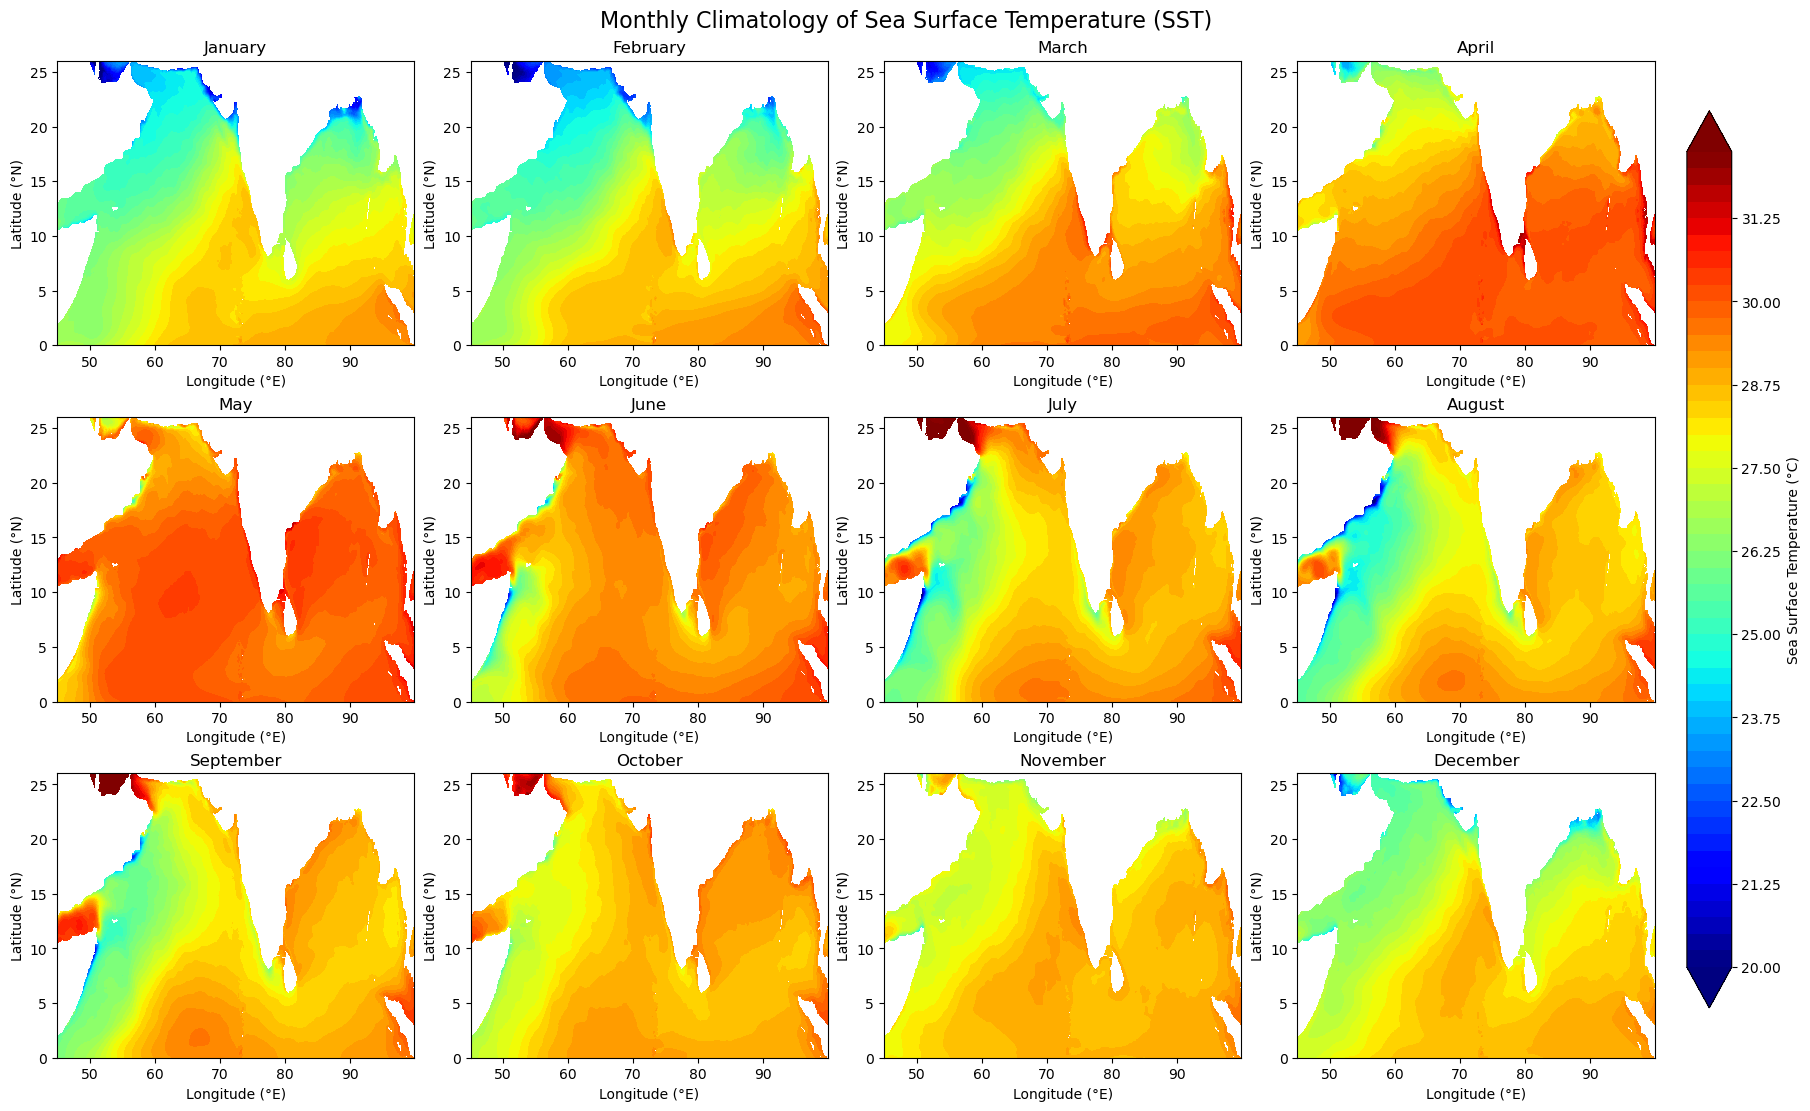

In [27]:
# Fixed contour levels for all months
levels = np.arange(20, 32.5, 0.25)

# Create 3 rows × 4 columns
fig, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(18, 11),
    constrained_layout=True
)

# Loop through all 12 months
for i, ax in enumerate(axes.flat):

    ## Select Variable and time index
    thetao_month = ds['thetao'].isel(time=i)

    cf = ax.contourf(
        ds['longitude'],
        ds['latitude'],
        thetao_month,
        levels=levels,
        cmap='jet',
        extend='both'
    )

    ax.set_title(thetao_month['time'].dt.strftime('%B').item())

    ax.set_xlabel('Longitude (°E)')
    ax.set_ylabel('Latitude (°N)')

# One common colorbar
cbar = fig.colorbar(
    cf,
    ax=axes,
    orientation='vertical',
    shrink=0.9,
    pad=0.02
)

cbar.set_label('Sea Surface Temperature (°C)')

fig.suptitle('Monthly Climatology of Sea Surface Temperature (SST)', fontsize=16)

plt.show()

## Salinity

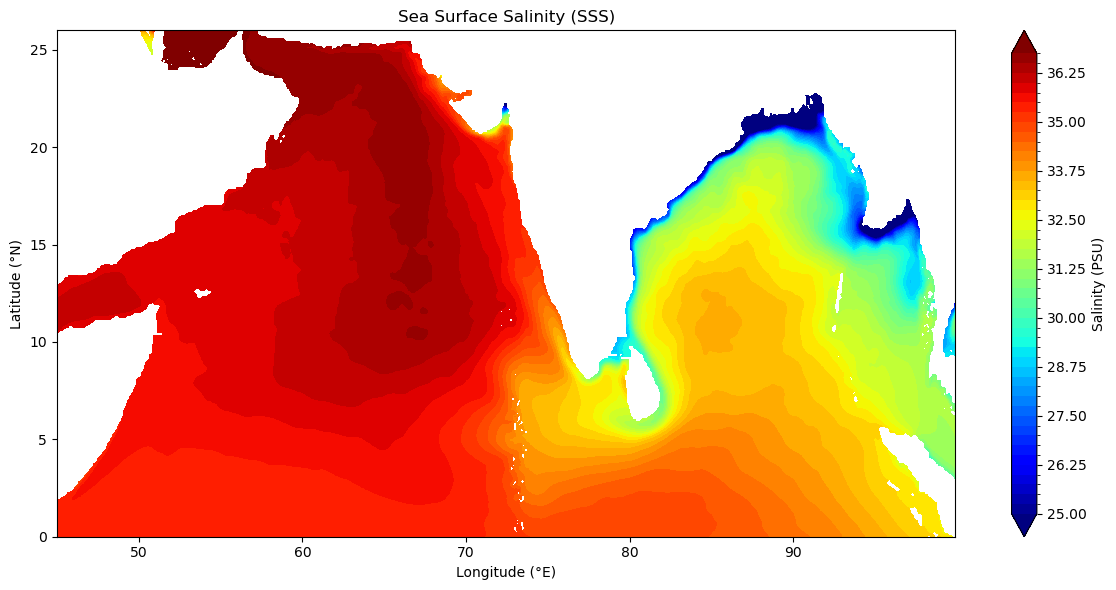

In [37]:
# Select Variable and Month
sss = ds['so'].sel(time='2004-12').squeeze()

# Spatial contourf plot
plt.figure(figsize=(12, 6))

sss.plot.contourf(
    x='longitude',
    y='latitude',
    cmap='jet',
    levels=np.arange(25, 37, 0.25),
    extend='both',
    cbar_kwargs={
        'label': 'Salinity (PSU)'
    }
)

plt.xlabel('Longitude (°E)')
plt.ylabel('Latitude (°N)')
plt.title('Sea Surface Salinity (SSS)')

plt.tight_layout()
plt.show()

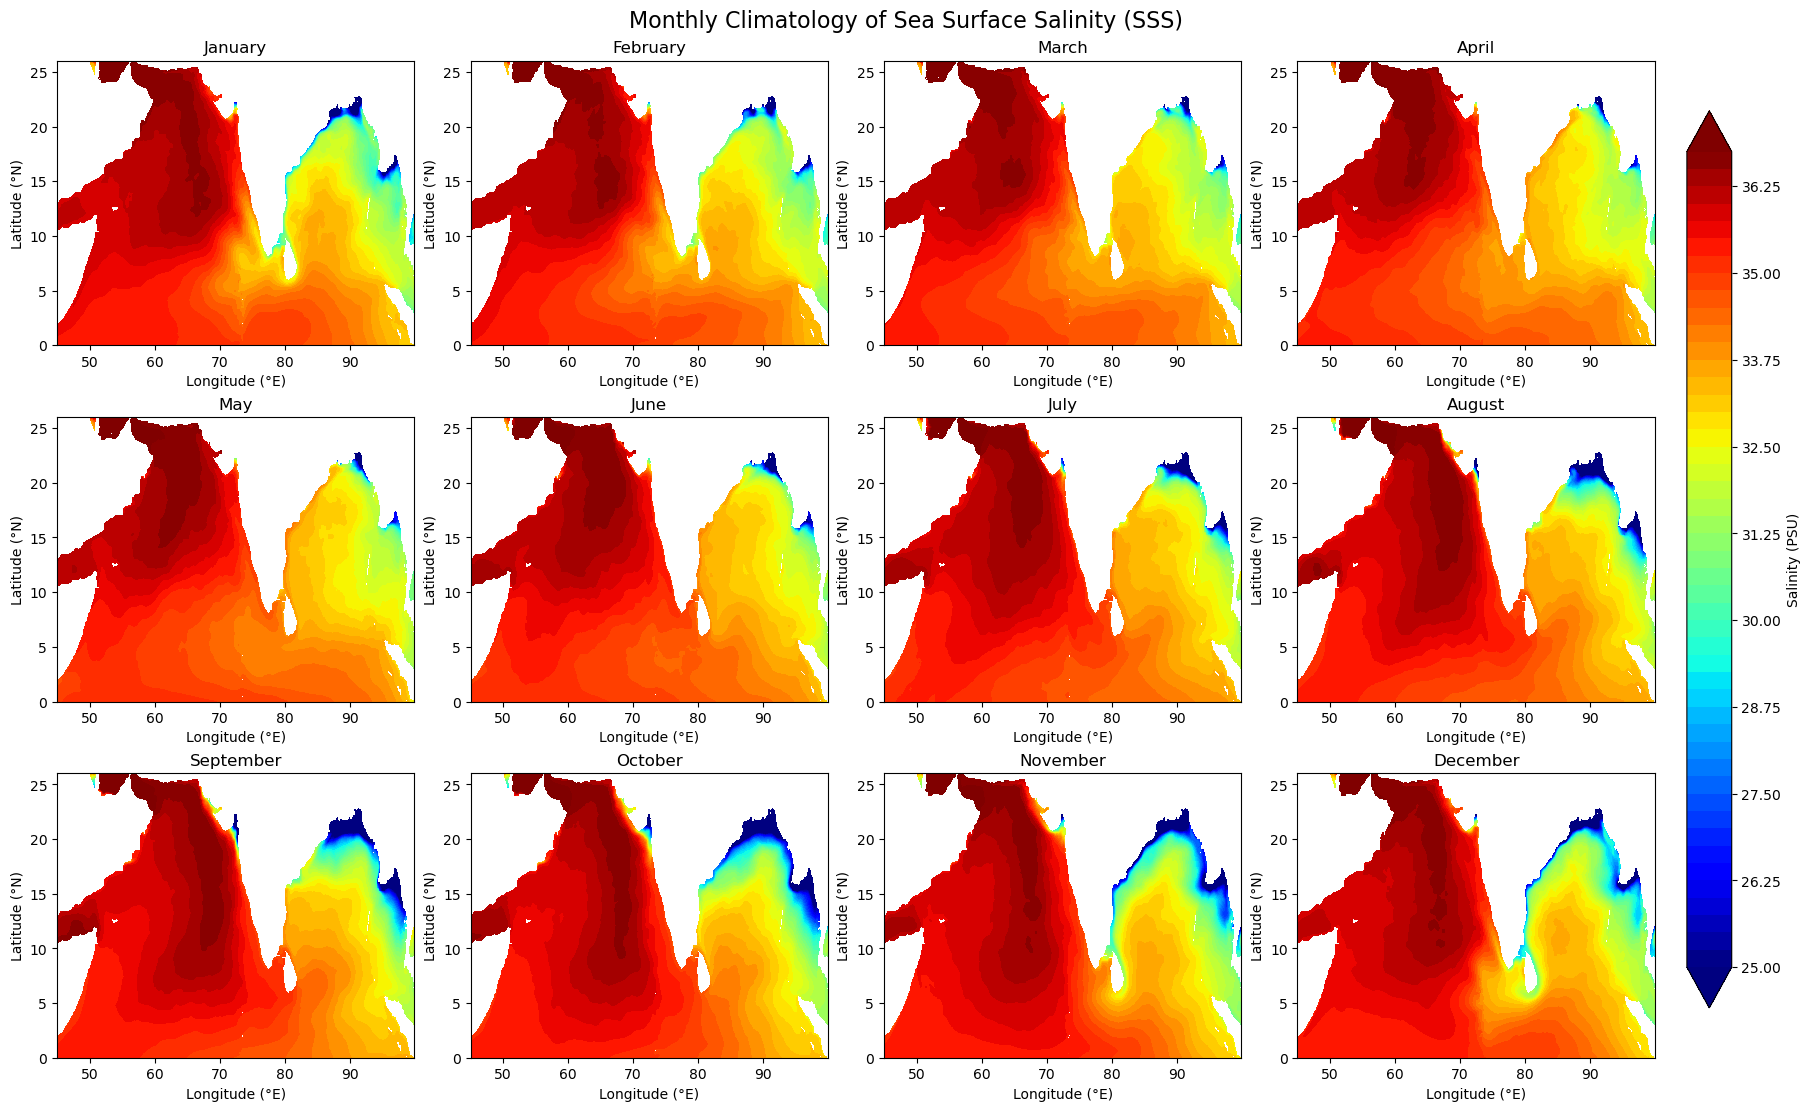

In [122]:
# Fixed contour levels for all months
levels = np.arange(25, 37, 0.25)

# Create 3 rows × 4 columns
fig, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(18, 11),
    constrained_layout=True
)

# Loop through all 12 months
for i, ax in enumerate(axes.flat):

    ## Select Variable and month index
    sss_month = ds['so'].isel(time=i)

    cf = ax.contourf(
        ds['longitude'],
        ds['latitude'],
        sss_month,
        levels=levels,
        cmap='jet',
        extend='both'
    )

    ax.set_title(sss_month['time'].dt.strftime('%B').item())

    ax.set_xlabel('Longitude (°E)')
    ax.set_ylabel('Latitude (°N)')

# One common colorbar
cbar = fig.colorbar(
    cf,
    ax=axes,
    orientation='vertical',
    shrink=0.9,
    pad=0.02
)

cbar.set_label('Salinity (PSU)')

fig.suptitle('Monthly Climatology of Sea Surface Salinity (SSS)', fontsize=16)

plt.show()

## Currents

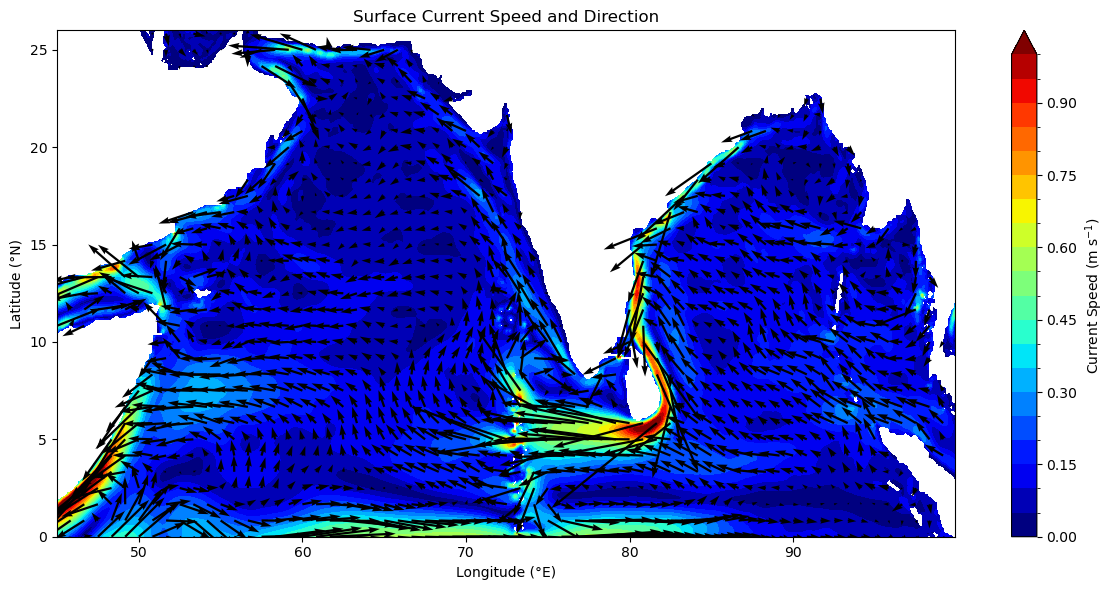

In [123]:
# Select Variable and Month
u = ds['uo'].sel(time='2004-12').squeeze()  ## Zonal Component
v = ds['vo'].sel(time='2004-12').squeeze()  ## Meridional Component

# Current speed magnitude
speed = np.sqrt(u**2 + v**2)

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Current speed contourf
speed.plot.contourf(
    x='longitude',
    y='latitude',
    cmap='jet',
    levels=np.arange(0, 1.01, 0.05),
    extend='max',
    cbar_kwargs={
        'label': 'Current Speed (m s$^{-1}$)'
    },
    ax=ax
)

# Create a coarser grid for vectors
skip = 10

lon = ds['longitude'].values
lat = ds['latitude'].values

# Current vectors
ax.quiver(
    lon[::skip],
    lat[::skip],
    u.values[::skip, ::skip],
    v.values[::skip, ::skip],
    scale=7,
    width=0.0025,
    color='black'
)

ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')
ax.set_title('Surface Current Speed and Direction')

plt.tight_layout()
plt.show()

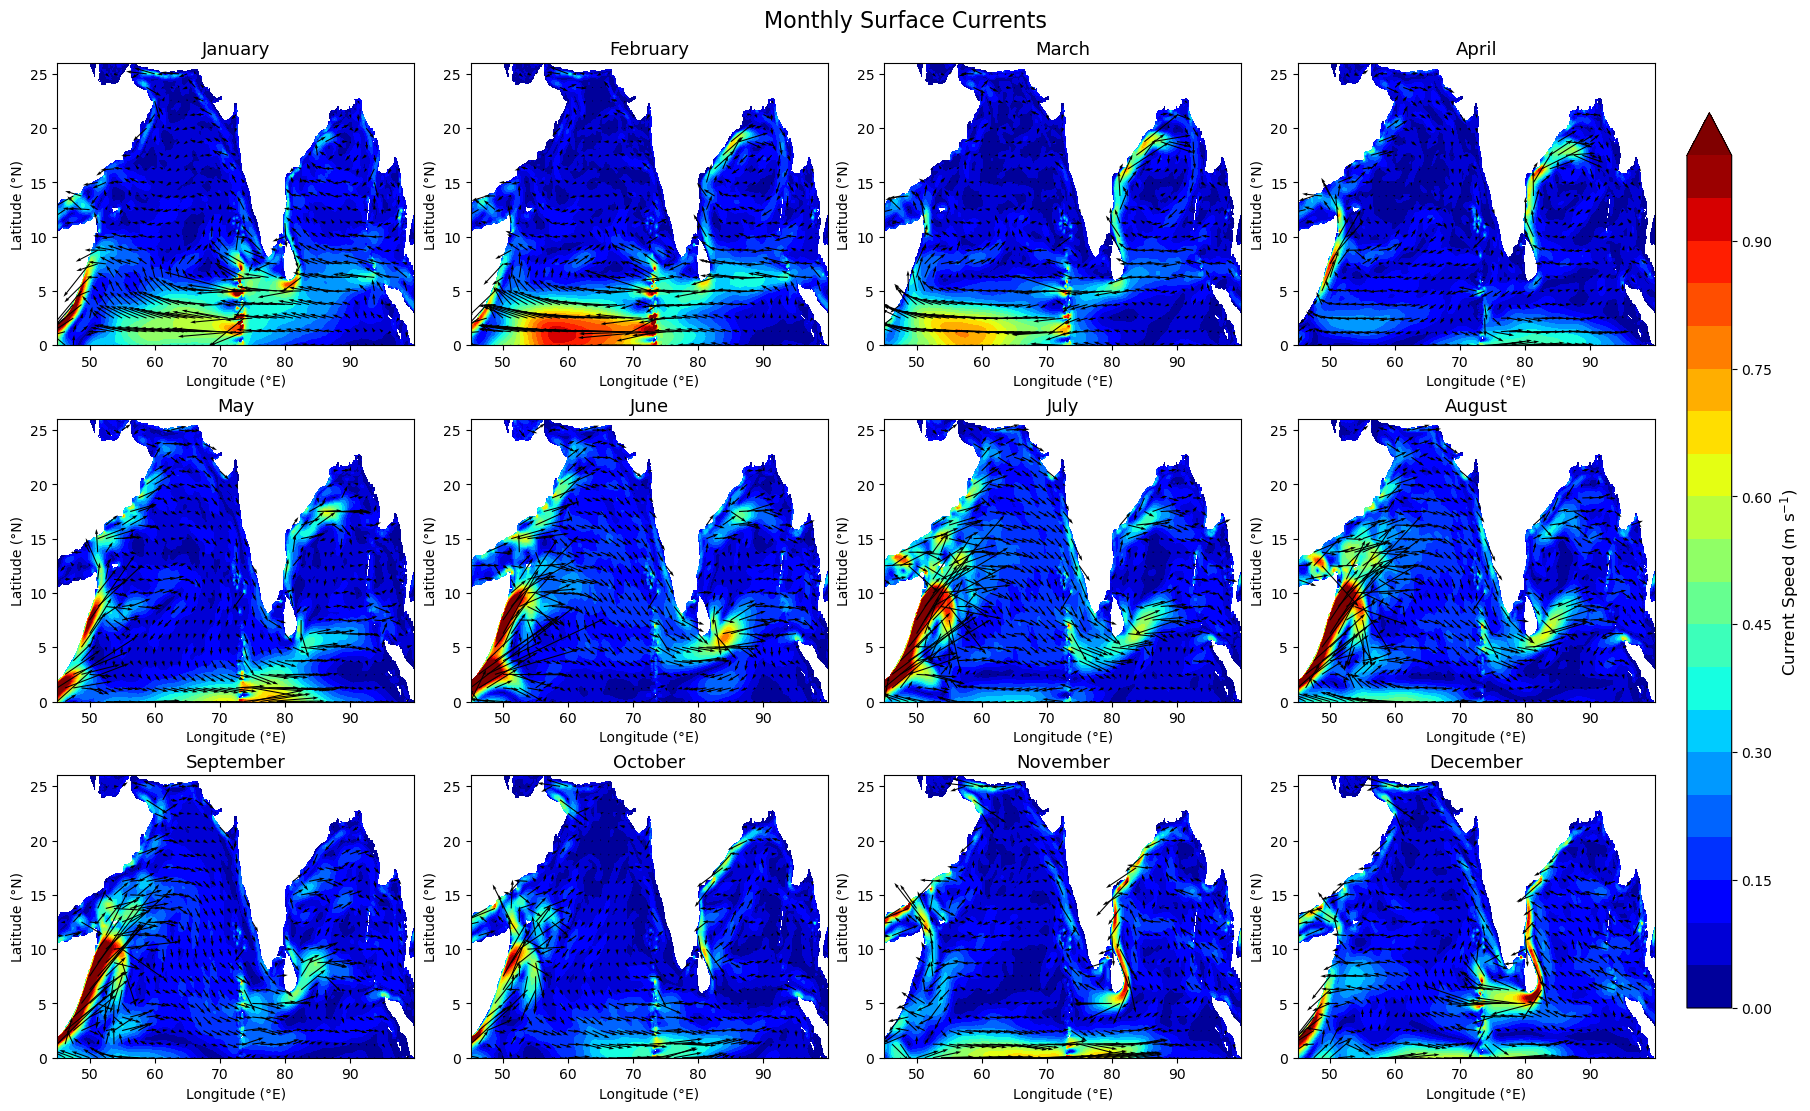

In [59]:
# Contour levels for current speed
levels = np.arange(0, 1.01, 0.05)

# Create 3 rows × 4 columns
fig, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(18, 11),
    constrained_layout=True
)

# Vector thinning (Skip latitide and longitude in between for better view)
skip = 15

for i, ax in enumerate(axes.flat):

    # Select monthly u and v
    u = ds['uo'].isel(time=i).squeeze()  ## Zonal
    v = ds['vo'].isel(time=i).squeeze()  ## Meridional

    # Current speed magnitude
    speed = np.sqrt(u**2 + v**2)

    # Contourf of current speed
    cf = ax.contourf(
        ds.longitude,
        ds.latitude,
        speed,
        levels=levels,
        cmap='jet',
        extend='max'
    )

    # Current vectors
    ax.quiver(
        ds.longitude.values[::skip],
        ds.latitude.values[::skip],
        u.values[::skip, ::skip],
        v.values[::skip, ::skip],
        color='black',
        scale=5,
        width=0.003
    )

    # Month title only
    month = u.time.dt.strftime('%B').item()
    ax.set_title(month, fontsize=13)

    ax.set_xlabel('Longitude (°E)')
    ax.set_ylabel('Latitude (°N)')

# Common colorbar
cbar = fig.colorbar(
    cf,
    ax=axes,
    orientation='vertical',
    pad=0.02,
    shrink=0.9
)

cbar.set_label(
    'Current Speed (m s$^{-1}$)',
    fontsize=12
)

fig.suptitle(
    'Monthly Surface Currents',
    fontsize=16
)

plt.show()

## Mixed Layer Depth (MLD)

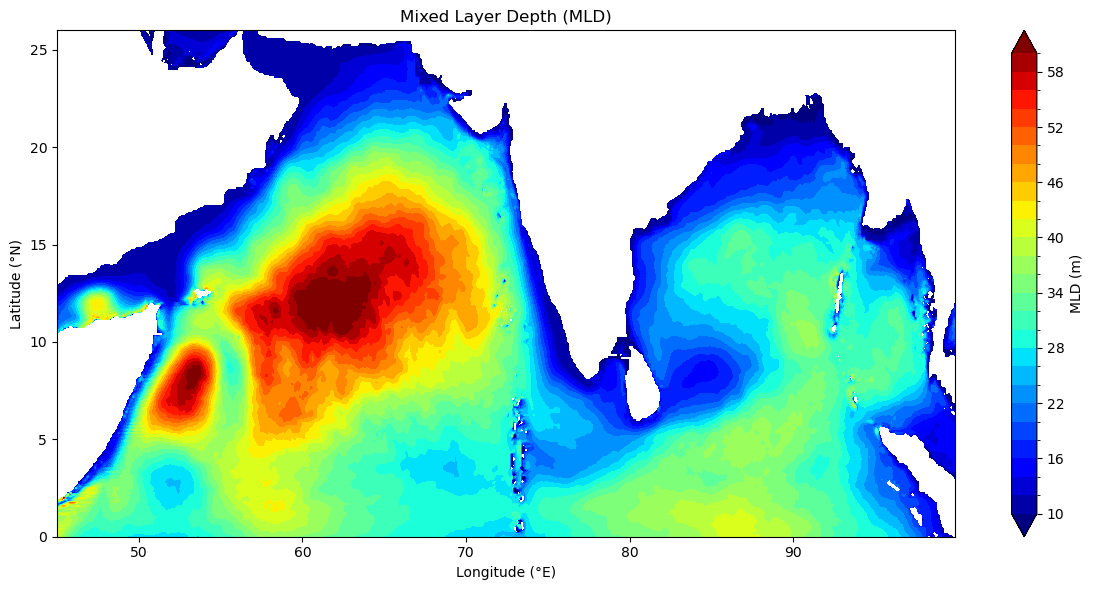

In [124]:
# Select Variable and Month
mld = ds['mlotst'].sel(time='2004-07').squeeze()

# Spatial contourf plot
plt.figure(figsize=(12, 6))

mld.plot.contourf(
    x='longitude',
    y='latitude',
    cmap='jet',
    levels=np.arange(10, 61, 2),
    extend='both',
    cbar_kwargs={
        'label': 'MLD (m)'
    }
)

plt.xlabel('Longitude (°E)')
plt.ylabel('Latitude (°N)')
plt.title('Mixed Layer Depth (MLD)')

plt.tight_layout()
plt.show()

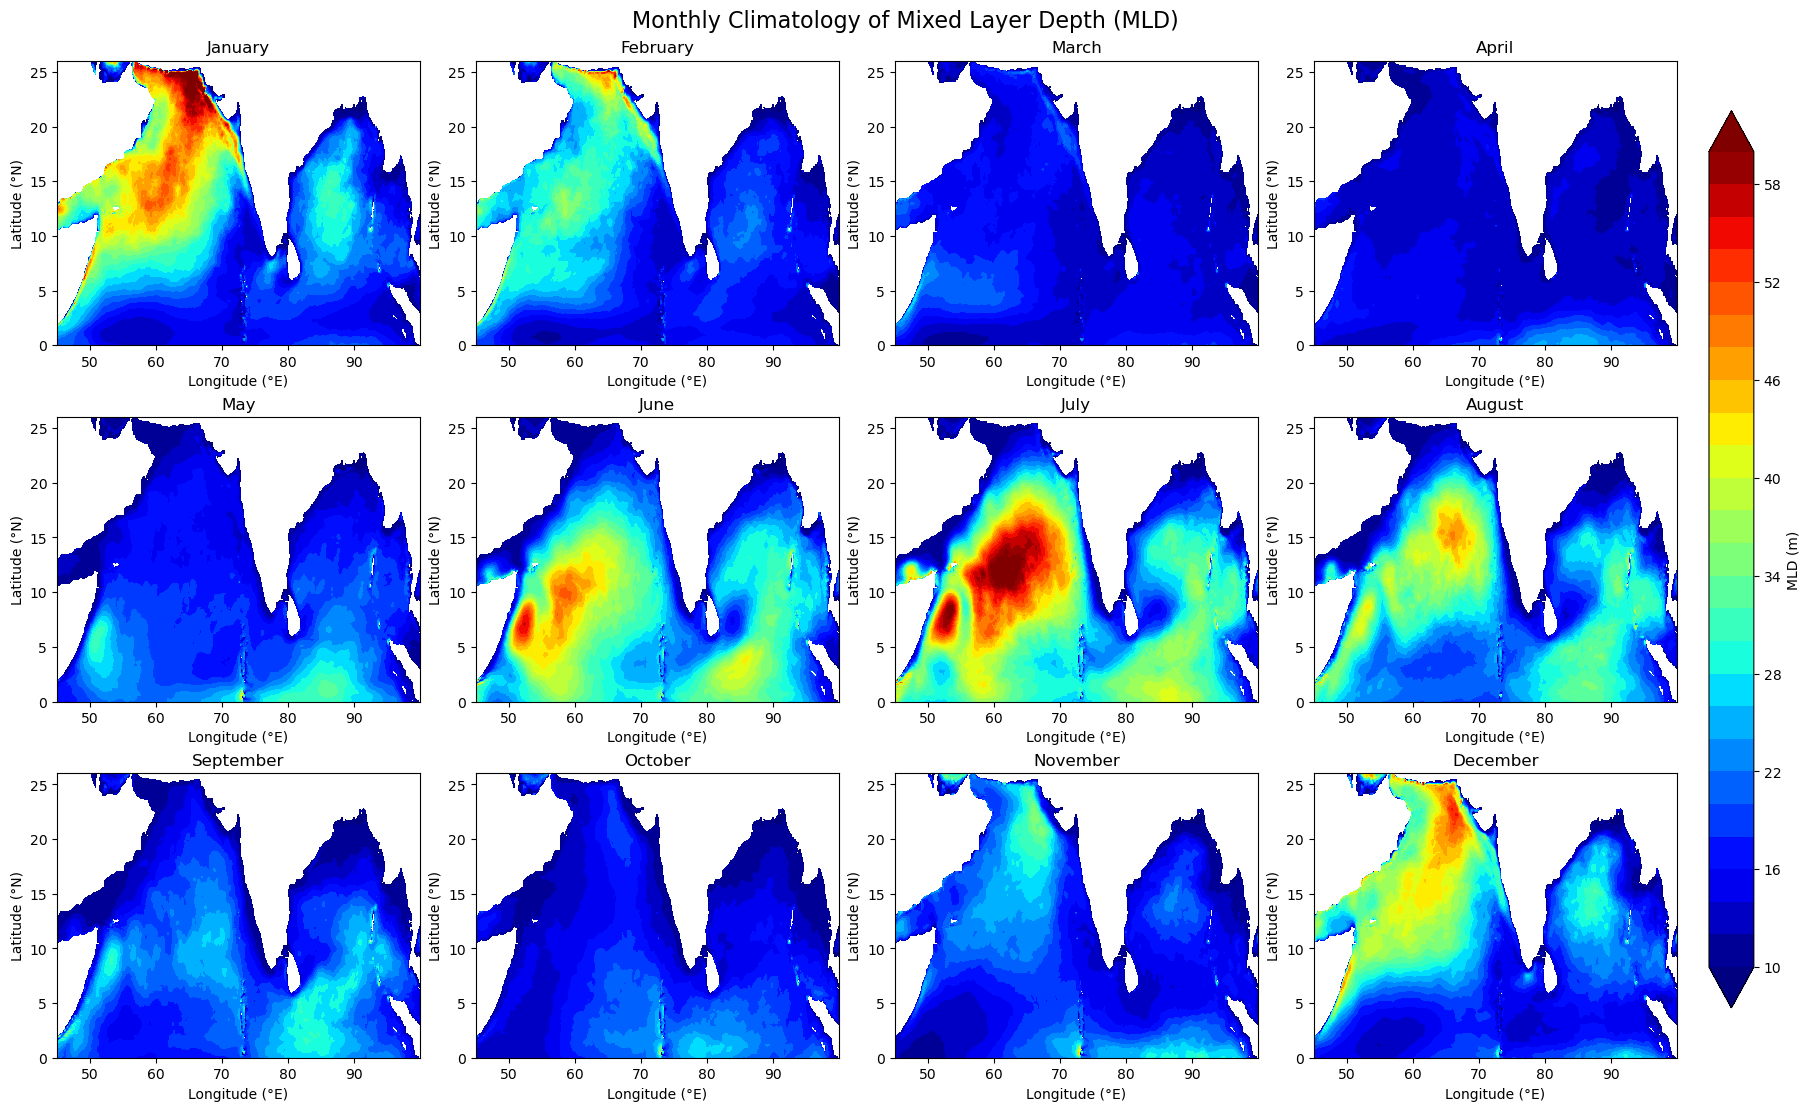

In [82]:
# Fixed contour levels for all months
levels = np.arange(10, 61, 2)

# Create 3 rows × 4 columns
fig, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(18, 11),
    constrained_layout=True
)

# Loop through all 12 months
for i, ax in enumerate(axes.flat):

    mld_month = ds['mlotst'].isel(time=i)

    cf = ax.contourf(
        ds['longitude'],
        ds['latitude'],
        mld_month,
        levels=levels,
        cmap='jet',
        extend='both'
    )

    ax.set_title(mld_month['time'].dt.strftime('%B').item())

    ax.set_xlabel('Longitude (°E)')
    ax.set_ylabel('Latitude (°N)')

# One common colorbar
cbar = fig.colorbar(
    cf,
    ax=axes,
    orientation='vertical',
    shrink=0.9,
    pad=0.02
)

cbar.set_label('MLD (m)')

fig.suptitle('Monthly Climatology of Mixed Layer Depth (MLD)', fontsize=16)

plt.show()

## Surface Heat Fluxes

In [83]:
ds_flux = xr.open_dataset('ERA5_All_Flux_Monthly_Climatology_IO_1993_2024.nc')

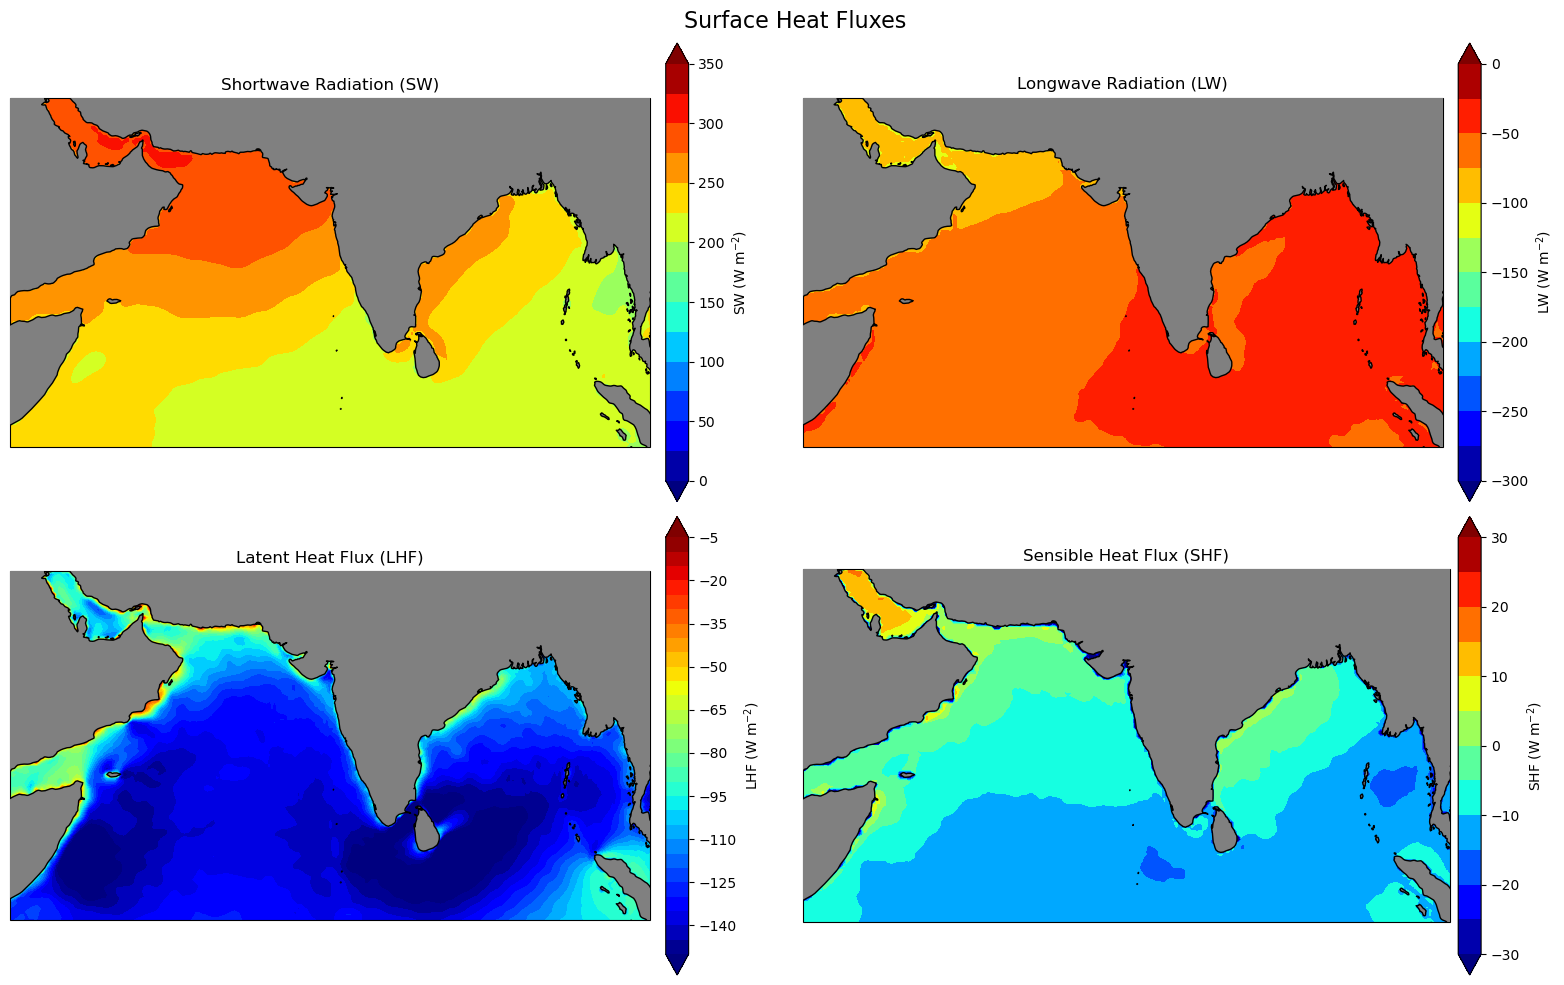

In [125]:
# Select Variable and Month
sw  = ds_flux['sw'].sel(time='2020-05').squeeze()
lw  = ds_flux['lw'].sel(time='2020-05').squeeze()
lhf = ds_flux['lhf'].sel(time='2020-05').squeeze()
shf = ds_flux['shf'].sel(time='2020-05').squeeze()

# Create 2 × 2 subplot
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(16, 10),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# ---------------- SW ----------------
cf1 = axes[0, 0].contourf(
    ds_flux.longitude,
    ds_flux.latitude,
    sw,
    levels=np.arange(0, 351, 25),
    cmap='jet',
    extend='both'
)

axes[0, 0].add_feature(cfeature.LAND,facecolor='gray',edgecolor='black',zorder=10)

axes[0, 0].set_title('Shortwave Radiation (SW)')
axes[0, 0].set_xlabel('Longitude (°E)')
axes[0, 0].set_ylabel('Latitude (°N)')

cbar1 = fig.colorbar(
    cf1,
    ax=axes[0, 0],
    pad=0.02
)
cbar1.set_label('SW (W m$^{-2}$)')


# ---------------- LW ----------------
cf2 = axes[0, 1].contourf(
    ds_flux.longitude,
    ds_flux.latitude,
    lw,
    levels=np.arange(-300, 1, 25),
    cmap='jet',
    extend='both'
)

axes[0, 1].add_feature(cfeature.LAND,facecolor='gray',edgecolor='black',zorder=10)

axes[0, 1].set_title('Longwave Radiation (LW)')
axes[0, 1].set_xlabel('Longitude (°E)')
axes[0, 1].set_ylabel('Latitude (°N)')

cbar2 = fig.colorbar(
    cf2,
    ax=axes[0, 1],
    pad=0.02
)
cbar2.set_label('LW (W m$^{-2}$)')


# ---------------- LHF ----------------
cf3 = axes[1, 0].contourf(
    ds_flux.longitude,
    ds_flux.latitude,
    lhf,
    levels=np.arange(-150, 0, 5),
    cmap='jet',
    extend='both'
)

axes[1, 0].add_feature(cfeature.LAND,facecolor='gray',edgecolor='black',zorder=10)

axes[1, 0].set_title('Latent Heat Flux (LHF)')
axes[1, 0].set_xlabel('Longitude (°E)')
axes[1, 0].set_ylabel('Latitude (°N)')

cbar3 = fig.colorbar(
    cf3,
    ax=axes[1, 0],
    pad=0.02
)
cbar3.set_label('LHF (W m$^{-2}$)')


# ---------------- SHF ----------------
cf4 = axes[1, 1].contourf(
    ds_flux.longitude,
    ds_flux.latitude,
    shf,
    levels=np.arange(-30, 31, 5),
    cmap='jet',
    extend='both'
)

axes[1, 1].add_feature(cfeature.LAND,facecolor='gray',edgecolor='black',zorder=10)

axes[1, 1].set_title('Sensible Heat Flux (SHF)')
axes[1, 1].set_xlabel('Longitude (°E)')
axes[1, 1].set_ylabel('Latitude (°N)')

cbar4 = fig.colorbar(
    cf4,
    ax=axes[1, 1],
    pad=0.01
)
cbar4.set_label('SHF (W m$^{-2}$)')


# Overall title
fig.suptitle('Surface Heat Fluxes',fontsize=16)

plt.tight_layout()
plt.show()

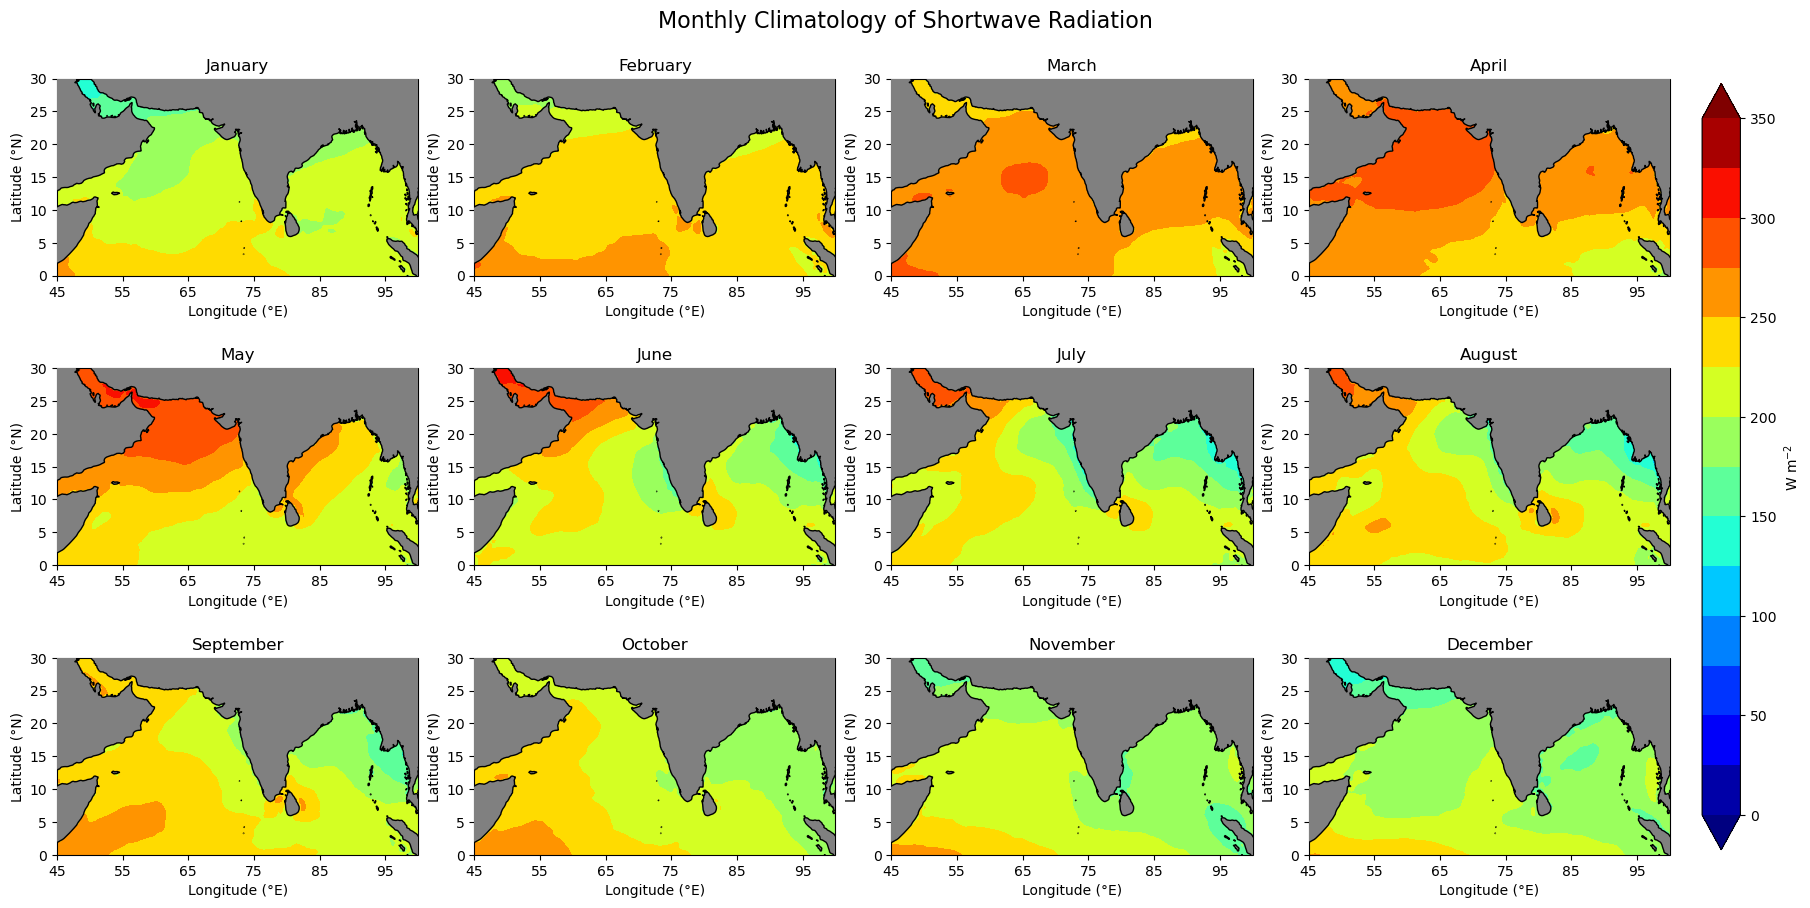

In [126]:
# Fixed contour levels for all months
levels = np.arange(0, 351, 25)

# Create 3 rows × 4 columns
fig, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(18, 9),
    constrained_layout=True,
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Loop through all 12 months
for i, ax in enumerate(axes.flat):

    flux_month = ds_flux['sw'].isel(time=i)

    cf = ax.contourf(
        ds_flux['longitude'],
        ds_flux['latitude'],
        flux_month,
        levels=levels,
        cmap='jet',
        extend='both'
    )

    ax.add_feature(
        cfeature.LAND,
        facecolor='gray',
        edgecolor='black',
        zorder=10
    )

    # Latitude and Longitude Ticks
    ax.set_xticks(np.arange(45, 101, 10))
    ax.set_yticks(np.arange(0, 31, 5))

    ax.set_title(flux_month['time'].dt.strftime('%B').item())

    ax.set_xlabel('Longitude (°E)')
    ax.set_ylabel('Latitude (°N)')

# One common colorbar
cbar = fig.colorbar(
    cf,
    ax=axes,
    orientation='vertical',
    shrink=0.9,
    pad=0.02
)

cbar.set_label('W m$^{-2}$')

fig.suptitle('Monthly Climatology of Shortwave Radiation', fontsize=16)

plt.show()

## Wind

In [103]:
ds_wind = xr.open_dataset('ERA5_Wind_Monthly_Climatology_IO_1993_2020.nc')

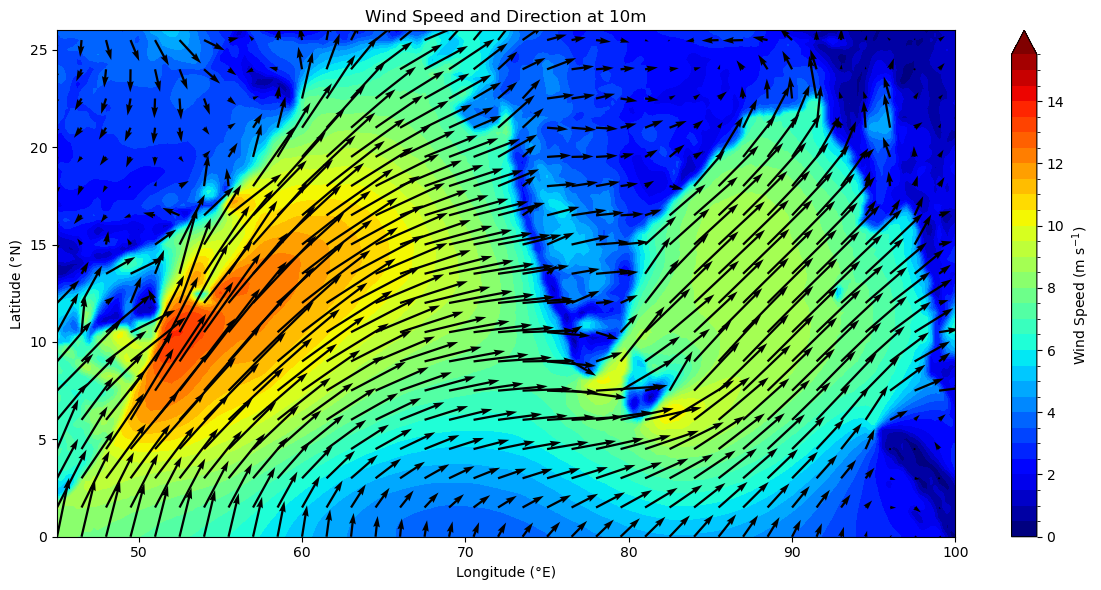

In [131]:
# Select Variable and Month
u = ds_wind['u10'].sel(time='2020-06').squeeze()
v = ds_wind['v10'].sel(time='2020-06').squeeze()
speed = ds_wind['speed10'].sel(time='2020-06').squeeze()

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Wind speed contourf
speed.plot.contourf(
    x='longitude',
    y='latitude',
    cmap='jet',
    levels=np.arange(0, 16, 0.5),
    extend='max',
    cbar_kwargs={
        'label': 'Wind Speed (m s$^{-1}$)'
    },
    ax=ax
)

# Create a coarser grid for vectors
skip = 6

lon = ds_wind['longitude'].values
lat = ds_wind['latitude'].values

# Wind vectors
ax.quiver(
    lon[::skip],
    lat[::skip],
    u.values[::skip, ::skip],
    v.values[::skip, ::skip],
    scale=120,
    width=0.0025,
    color='black'
)

ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')
ax.set_title('Wind Speed and Direction at 10m')

plt.tight_layout()
plt.show()

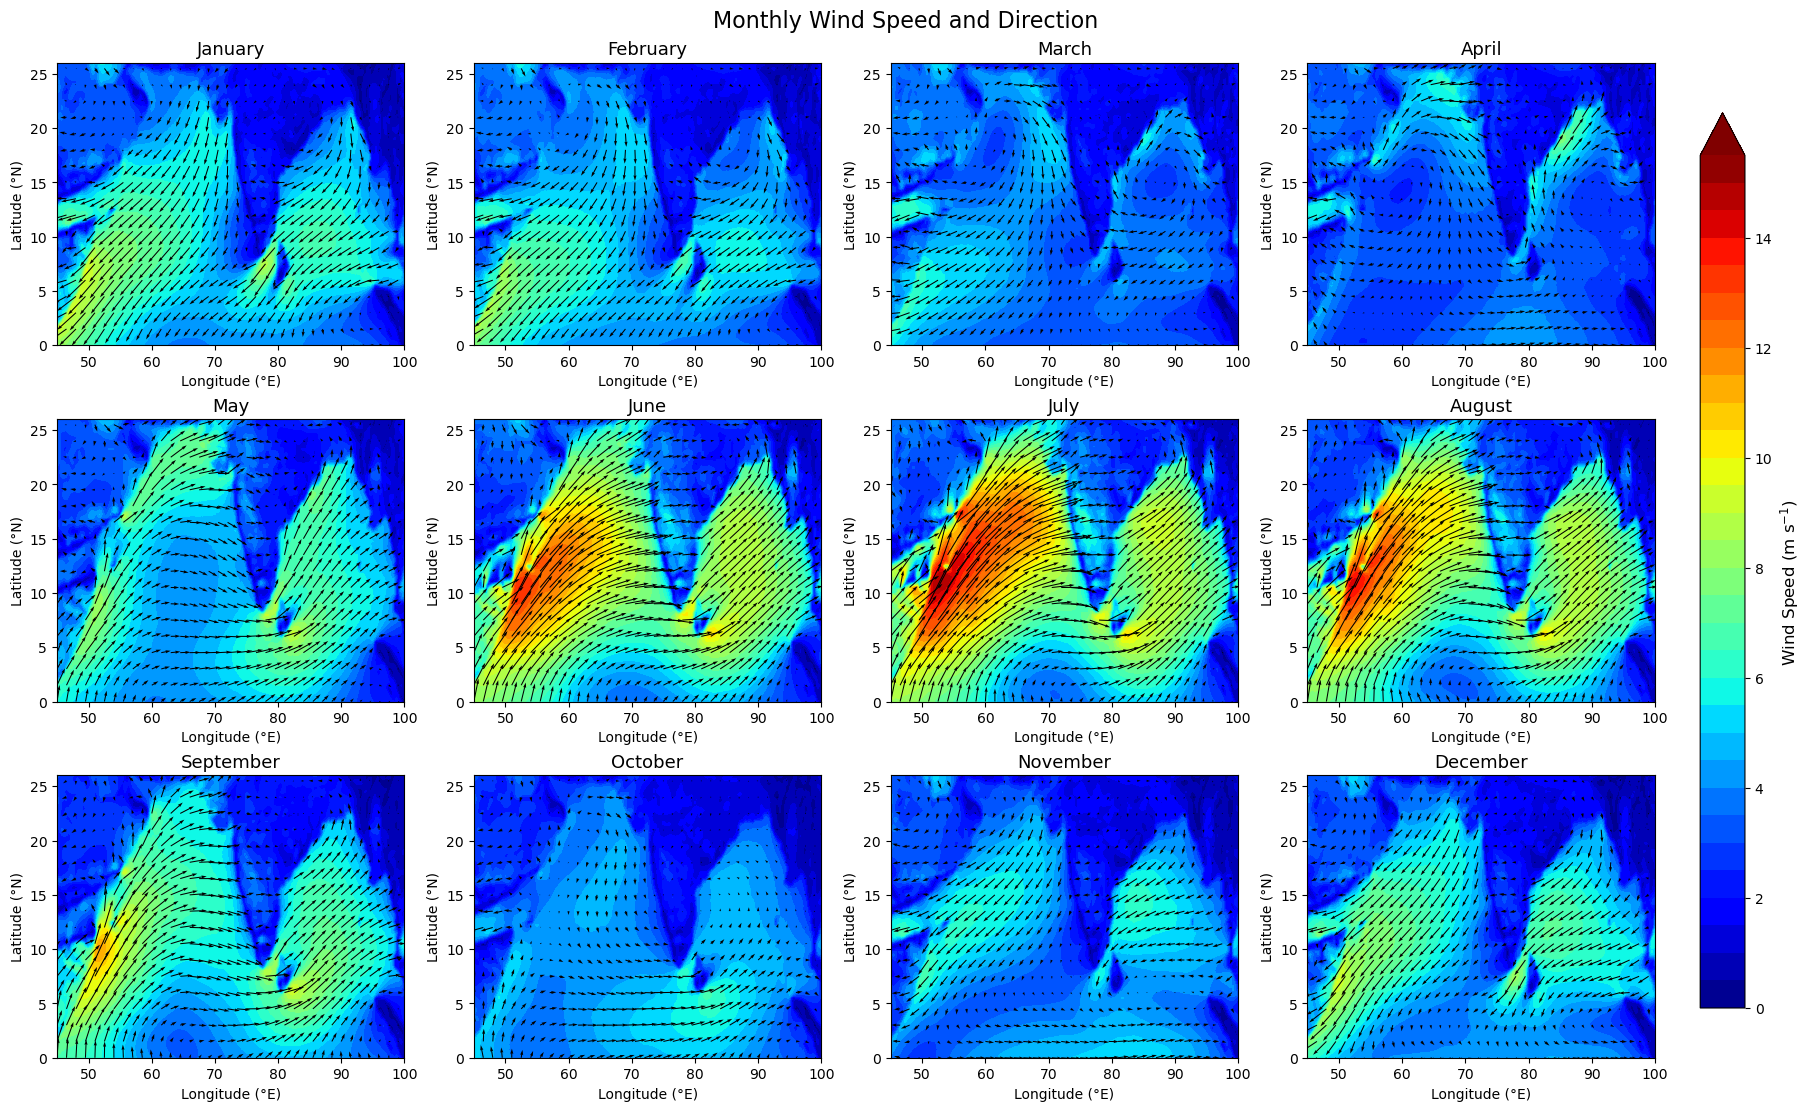

In [129]:
# Contour levels for Wind speed
levels = np.arange(0, 16, 0.5)

# Create 3 rows × 4 columns
fig, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(18, 11),
    constrained_layout=True
)

# Vector thinning (Skip latitide and longitude in between for better view)
skip = 6

for i, ax in enumerate(axes.flat):

    # Select monthly u and v
    u = ds_wind['u10'].isel(time=i).squeeze()
    v = ds_wind['v10'].isel(time=i).squeeze()
    speed = ds_wind['speed10'].isel(time=i).squeeze()

    # Contourf of wind speed
    cf = ax.contourf(
        ds_wind.longitude,
        ds_wind.latitude,
        speed,
        levels=levels,
        cmap='jet',
        extend='max'
    )

    # wind vectors
    ax.quiver(
        ds_wind.longitude.values[::skip],
        ds_wind.latitude.values[::skip],
        u.values[::skip, ::skip],
        v.values[::skip, ::skip],
        color='black',
        scale=120,
        width=0.003
    )

    # Month title only
    month = u.time.dt.strftime('%B').item()
    ax.set_title(month, fontsize=13)

    ax.set_xlabel('Longitude (°E)')
    ax.set_ylabel('Latitude (°N)')

# Common colorbar
cbar = fig.colorbar(
    cf,
    ax=axes,
    orientation='vertical',
    pad=0.02,
    shrink=0.9
)

cbar.set_label('Wind Speed (m s$^{-1}$)',fontsize=12)

fig.suptitle('Monthly Wind Speed and Direction', fontsize=16)

plt.show()